# Feature Engineering

We now want to turn the findings from the EDA into a modelling table. 

## Imports

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import MatplotlibDeprecationWarning
import seaborn as sns

warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

sns.set_theme(style="whitegrid")

## Loading the training and test data

In [2]:
train_df = pd.read_csv("data/fraudTrain.csv", index_col=0)
test_df = pd.read_csv("data/fraudTest.csv", index_col=0)

train_df["source"] = "train"
test_df["source"] = "test"

print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")

Training rows: 1,296,675
Test rows: 555,719


In [3]:
period_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Start": [
        pd.to_datetime(train_df["trans_date_trans_time"]).min(),
        pd.to_datetime(test_df["trans_date_trans_time"]).min(),
    ],
    "End": [
        pd.to_datetime(train_df["trans_date_trans_time"]).max(),
        pd.to_datetime(test_df["trans_date_trans_time"]).max(),
    ],
    "Rows": [len(train_df), len(test_df)],
    "Fraud rate": [train_df["is_fraud"].mean(), test_df["is_fraud"].mean()],
})

period_summary

,Dataset,Start,End,Rows,Fraud rate
0,Training,2019-01-01 00:00:18,2020-06-21 12:13:37,1296675,0.005789
1,Test,2020-06-21 12:14:25,2020-12-31 23:59:34,555719,0.003860


The test file contains later transactions. We combine the files only so each transaction can use the cardholder's genuinely earlier activity, then separate them again using the `source` column. This assumes transactions are scored in time order. The target is never used to create a feature.

## Creating one chronological transaction table

In [4]:
transactions = pd.concat([train_df, test_df], ignore_index=True)
transactions["trans_date_trans_time"] = pd.to_datetime(transactions["trans_date_trans_time"])

transactions = transactions.sort_values(
    ["trans_date_trans_time", "trans_num"],
    kind="mergesort",
).reset_index(drop=True)

print("Transactions are in time order:", transactions["trans_date_trans_time"].is_monotonic_increasing)

Transactions are in time order: True


## Static transaction features

### Transaction amount and city population

Transaction amount and city population both have long right tails, so we use `log(1 + x)` to reduce the influence of a small number of very large values. The ordering is unchanged. The EDA suggests amount is much more informative, while city population is kept as an initial candidate to assess later.

In [5]:
transactions["log_amount"] = np.log1p(transactions["amt"])
transactions["log_city_population"] = np.log1p(transactions["city_pop"])

transactions[["amt", "log_amount", "city_pop", "log_city_population"]].head()

,amt,log_amount,city_pop,log_city_population
0,4.97,1.786747,3495,8.159375
1,107.23,4.684259,149,5.010635
2,220.11,5.398660,4154,8.332068
3,45.00,3.828641,1939,7.570443
4,41.96,3.760269,99,4.605170


### Cyclical time features

Clock time repeats. Although 23:00 and 00:00 are only one hour apart, their raw values make them look 23 hours apart. We use sine and cosine to place each hour around a circle, so the end of the day is next to the beginning. The same idea is used for weekday and month.

We keep the original values as well as the cyclical versions. Tree models can make useful direct splits on the original values, while the cyclical versions give Logistic Regression a clearer representation of neighbouring times.

In [6]:
hour = transactions["trans_date_trans_time"].dt.hour
weekday = transactions["trans_date_trans_time"].dt.dayofweek
month_index = transactions["trans_date_trans_time"].dt.month - 1

transactions["transaction_hour"] = hour
transactions["transaction_weekday"] = weekday
transactions["transaction_month"] = month_index + 1
transactions["hour_sin"] = np.sin(2 * np.pi * hour / 24)
transactions["hour_cos"] = np.cos(2 * np.pi * hour / 24)
transactions["weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
transactions["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)
transactions["month_sin"] = np.sin(2 * np.pi * month_index / 12)
transactions["month_cos"] = np.cos(2 * np.pi * month_index / 12)

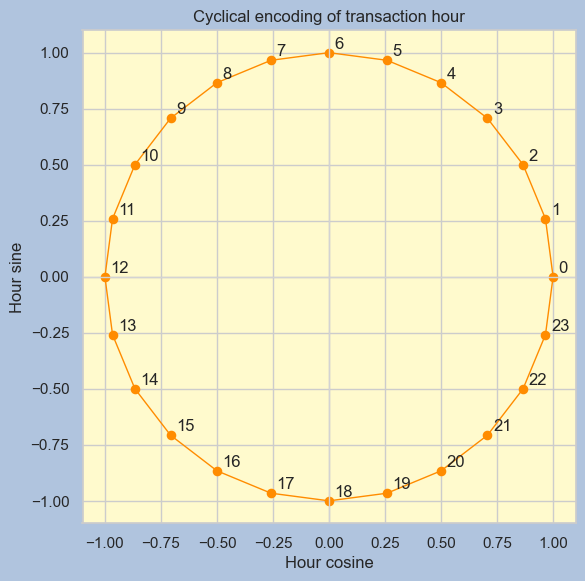

In [7]:
hour_example = pd.DataFrame({"Hour": np.arange(24)})
hour_example["Hour sine"] = np.sin(2 * np.pi * hour_example["Hour"] / 24)
hour_example["Hour cosine"] = np.cos(2 * np.pi * hour_example["Hour"] / 24)

hour_sine = hour_example["Hour sine"].to_numpy()
hour_cosine = hour_example["Hour cosine"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 6), facecolor="lightsteelblue")
ax.plot(
    np.append(hour_cosine, hour_cosine[0]),
    np.append(hour_sine, hour_sine[0]),
    color="darkorange",
    linewidth=1,
)
ax.scatter(
    hour_cosine,
    hour_sine,
    color="darkorange",
    s=35,
)
for _, row in hour_example.iterrows():
    ax.annotate(
        int(row["Hour"]),
        (row["Hour cosine"], row["Hour sine"]),
        xytext=(4, 3),
        textcoords="offset points",
    )
ax.axhline(0, color="lightgrey", linewidth=1)
ax.axvline(0, color="lightgrey", linewidth=1)
ax.set_title("Cyclical encoding of transaction hour")
ax.set_xlabel("Hour cosine")
ax.set_ylabel("Hour sine")
ax.set_facecolor("lemonchiffon")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Customer-to-merchant distance

The Haversine formula converts the customer and merchant coordinates into one distance in kilometres. NumPy calculates every distance together rather than using a slow row-by-row loop. The EDA showed little difference between the two classes, so we keep distance as an initial candidate and assess its contribution later.

In [8]:
customer_latitude = np.radians(transactions["lat"])
customer_longitude = np.radians(transactions["long"])
merchant_latitude = np.radians(transactions["merch_lat"])
merchant_longitude = np.radians(transactions["merch_long"])

latitude_difference = merchant_latitude - customer_latitude
longitude_difference = merchant_longitude - customer_longitude
haversine_value = (
    np.sin(latitude_difference / 2) ** 2
    + np.cos(customer_latitude)
    * np.cos(merchant_latitude)
    * np.sin(longitude_difference / 2) ** 2
)
transactions["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(haversine_value))

transactions["distance_km"].describe().round(2)

count    1852394.00
mean          76.11
std           29.12
min            0.02
25%           55.32
50%           78.22
75%           98.51
max          152.12
Name: distance_km, dtype: float64

## Earlier cardholder behaviour

These features answer how recently did this cardholder transact, and is the current amount unusual compared with their own earlier spending?

We first create one row per cardholder and timestamp, preventing transactions recorded at exactly the same moment from being treated as history for one another.

In [9]:
cardholder_time = (
    transactions.groupby(["cc_num", "trans_date_trans_time"], as_index=False)
    .agg(Amount_at_time=("amt", "sum"), Transactions_at_time=("amt", "size"))
    .sort_values(["cc_num", "trans_date_trans_time"], kind="mergesort")
)

by_cardholder = cardholder_time.groupby("cc_num", sort=False)
cardholder_time["prior_transaction_count"] = (
    by_cardholder["Transactions_at_time"].cumsum()
    - cardholder_time["Transactions_at_time"]
)
cardholder_time["prior_amount_sum"] = (
    by_cardholder["Amount_at_time"].cumsum()
    - cardholder_time["Amount_at_time"]
)
cardholder_time["prior_mean_amount"] = (
    cardholder_time["prior_amount_sum"]
    / cardholder_time["prior_transaction_count"].replace(0, np.nan)
)
cardholder_time["previous_transaction_time"] = (
    by_cardholder["trans_date_trans_time"].shift()
)

In [10]:
transactions = transactions.merge(
    cardholder_time[[
        "cc_num", "trans_date_trans_time", "prior_transaction_count",
        "prior_mean_amount", "previous_transaction_time",
    ]],
    on=["cc_num", "trans_date_trans_time"],
    how="left",
    validate="many_to_one",
)

hours_since_previous = (
    transactions["trans_date_trans_time"]
    - transactions["previous_transaction_time"]
).dt.total_seconds() / 3600

transactions["log_hours_since_previous"] = np.log1p(
    hours_since_previous.clip(lower=0)
).fillna(0)
transactions["amount_to_prior_mean"] = (
    transactions["amt"] / transactions["prior_mean_amount"]
).clip(upper=20).fillna(1)

In [11]:
history_example = transactions.loc[
    transactions["cc_num"] == transactions["cc_num"].value_counts().index[0],
    [
        "trans_date_trans_time", "amt", "prior_transaction_count",
        "prior_mean_amount", "amount_to_prior_mean",
    ],
].head(8)

history_example

,trans_date_trans_time,amt,prior_transaction_count,prior_mean_amount,amount_to_prior_mean
1195,2019-01-01 14:14:45,1.57,0,NaN,1.000000
1533,2019-01-01 16:37:08,267.29,1,1.570000,20.000000
1805,2019-01-01 19:00:06,229.30,2,134.430000,1.705720
2641,2019-01-02 06:15:58,73.69,3,166.053333,0.443773
3029,2019-01-02 15:19:35,108.75,4,142.962500,0.760689
4749,2019-01-03 23:45:58,20.72,5,136.120000,0.152219
5685,2019-01-04 16:54:41,1.52,6,116.886667,0.013004
7950,2019-01-06 04:20:13,63.18,7,100.405714,0.629247


The first transaction has no history, so its prior count is zero, its elapsed time is set to zero and its amount ratio is set to one. 

We cap the ratio at 20 so a very small earlier mean cannot create an extreme value. Every later row uses only amounts that occurred previously. The card number is needed to build these features but is not passed to the model itself.

## Selecting the model features

Transaction amount, time, merchant category and the two history measures showed the clearest patterns in the EDA. We also keep city population and customer-to-merchant distance as weaker numerical candidates.

Age and gender are examined in the EDA but are not included in the model table.

In [12]:
numeric_features = [
    "log_amount",
    "log_city_population",
    "distance_km",
    "transaction_hour",
    "transaction_weekday",
    "transaction_month",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "log_hours_since_previous",
    "amount_to_prior_mean",
]
categorical_features = ["category"]

feature_table = transactions[
    ["source", "trans_date_trans_time", "is_fraud"]
    + numeric_features
    + categorical_features
].copy()

train_feature_table = feature_table[feature_table["source"] == "train"].drop(columns="source")
test_feature_table = feature_table[feature_table["source"] == "test"].drop(columns="source")

train_features = pd.get_dummies(
    train_feature_table,
    columns=categorical_features,
    dtype="int8",
)
test_features = pd.get_dummies(
    test_feature_table,
    columns=categorical_features,
    dtype="int8",
)
test_features = test_features.reindex(columns=train_features.columns, fill_value=0)

print("Training feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)
print("Number of model features:", train_features.shape[1] - 2)

Training feature shape: (1296675, 30)
Test feature shape: (555719, 30)
Number of model features: 28


## Final checks

In [13]:
model_columns = [
    column for column in train_features.columns
    if column not in ["trans_date_trans_time", "is_fraud"]
]

history_rows = transactions["previous_transaction_time"].notna()
excluded_fields = {
    "age", "gender", "dob", "first", "last", "street", "city",
    "state", "zip", "job", "merchant", "cc_num", "trans_num",
    "unix_time", "amt", "city_pop", "lat", "long", "merch_lat",
    "merch_long",
}

checks = pd.Series({
    "One training row per transaction": len(train_features) == len(train_df),
    "One test row per transaction": len(test_features) == len(test_df),
    "Training and test columns match": train_features.columns.equals(test_features.columns),
    "No missing training values": train_features[model_columns].isna().sum().sum() == 0,
    "No missing test values": test_features[model_columns].isna().sum().sum() == 0,
    "No infinite training values": np.isfinite(train_features[model_columns].to_numpy()).all(),
    "No infinite test values": np.isfinite(test_features[model_columns].to_numpy()).all(),
    "History uses only earlier timestamps": (
        transactions.loc[history_rows, "previous_transaction_time"]
        < transactions.loc[history_rows, "trans_date_trans_time"]
    ).all(),
    "Excluded raw fields are absent": excluded_fields.isdisjoint(model_columns),
    "Distances are non-negative": transactions["distance_km"].ge(0).all(),
})

checks.to_frame("Passed")

,Passed
One training row per transaction,True
One test row per transaction,True
Training and test columns match,True
No missing training values,True
No missing test values,True
No infinite training values,True
No infinite test values,True
History uses only earlier timestamps,True
Excluded raw fields are absent,True
Distances are non-negative,True


$$
\begin{array}{ll}
\hline
\textbf{Feature} & \textbf{Reason} \\
\hline
\text{log\_amount} &
\text{Transaction amount with its long right tail reduced} \\

\text{log\_city\_population} &
\text{Initial city-size candidate with its long right tail reduced} \\

\text{distance\_km} &
\text{Distance between the customer and merchant} \\

\text{transaction\_hour, transaction\_weekday, transaction\_month} &
\text{Original time values which tree models can split directly} \\

\text{hour\_sin, hour\_cos} &
\text{Hour represented as a repeating cycle} \\

\text{weekday\_sin, weekday\_cos} &
\text{Day of week represented as a repeating cycle} \\

\text{month\_sin, month\_cos} &
\text{Month represented as a repeating cycle} \\

\text{log\_hours\_since\_previous} &
\text{Time since the cardholder's previous transaction} \\

\text{amount\_to\_prior\_mean} &
\text{Current amount compared with the cardholder's earlier mean} \\

\text{category} &
\text{Merchant category converted to dummy variables} \\
\hline
\end{array}
$$

## Summary

The final table contains 28 model features which follow directly from the EDA. Transaction amount, time, merchant category and cardholder history showed the clearest patterns. We also retain city population and customer-to-merchant distance as weaker numerical candidates.

Age and gender are examined in the EDA but are not used to train the model. Date of birth, names, addresses, job title, merchant name, card number, transaction ID and state are also excluded. Raw amount, city population and coordinates are used only to create the derived features, while the timestamp is retained only for chronological splitting.

The same transformations are stored in `feature_engineering.py`, which the model-comparison notebook calls directly. This avoids duplicating the full preparation code while leaving every step explained here.